In [ ]:
import pennylane as qml
import numpy as np
from pennylane.ops import Prod
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import jax
import jax.numpy as jnp
import jax.random as jrand
import itertools
import time

from optimise import optLoopAdamW
from vqeSetup import TFHamiltonianRevised, exactSolution, ansatz, local_cost_fn, getRho
import warnings
warnings.filterwarnings("ignore", category=np.exceptions.ComplexWarning)

In [2]:
def exactSolution(HMatrix):
    evals, evecs = np.linalg.eigh(HMatrix)
    posOfMinEval = np.flatnonzero(evals == evals.min())
    GrStateE = evals[posOfMinEval[0]]
    GrStates = evecs[:,posOfMinEval]
    return evals, GrStateE, GrStates

def TFHamiltonianRevised(J,h,disorder,dims):
    x = 2 if disorder else 1 #used to skip wires when disorder is true
    coeffs = jnp.concatenate([h,-J])
    ops = [qml.X(x*i) for i in range(len(h))]
    ops.extend([(qml.Z(x*i) @ qml.Z((x*(i + 1)))) for i in range(len(J)-1)])
    ops.extend([(qml.Z(x*(len(J)-1)) @ qml.Z(0))])

    hamiltonian = qml.Hamiltonian(coeffs, ops)
    return hamiltonian

In [3]:
def createDisorderTrainingCases(n, trainingSize, testSize, seed, includeTheseJs=None):
    
    total_needed = trainingSize + testSize
    key = jrand.PRNGKey(seed)        

    if includeTheseJs is not None:
        assert (np.unique(jnp.asarray(includeTheseJs), axis=0).shape[0] == includeTheseJs.shape[0]), "Input J's should be unique"
        assert includeTheseJs.shape[0] <= trainingSize, f"too many J's to include for the training size of {trainingSize}"
        includeTheseJs = jnp.array(includeTheseJs)
        assert includeTheseJs.shape[1] == n, "Each included J must have length n"
        selected_set = set(tuple(row.tolist()) for row in includeTheseJs)
        selected = [tuple(row.tolist()) for row in includeTheseJs]
    else:
        selected_set = set()
        selected = []

    remaining = total_needed - len(selected)
    assert remaining >= 0, f"Too many includeTheseJs for trainingSize of {trainingSize}"

    if remaining == 0:
        pass  # already have all needed
    elif total_needed > 2**(n - 1): # Full enumeration if more than half of cases needed: slow for big n, fast for small n
        all_configs = jnp.array(list(itertools.product([-1, 1], repeat=n)))
        all_configs_set = set(tuple(row.tolist()) for row in all_configs)
        available = list(all_configs_set - selected_set)
        key, subkey = jrand.split(key)
        chosen_indices = jrand.choice(subkey, len(available), shape=(remaining,), replace=False)
        for idx in chosen_indices:
            vec = tuple(available[idx])
            selected.append(vec)
            selected_set.add(vec)
    else:  # While loop if less than half of cases needed: slow for small n AND wanting most cases in training set
        i = 0 #note currently you never do this loop since total_needed = 2^n always
        while len(selected) < total_needed:
            key_i = jrand.PRNGKey(seed + i)
            vec = tuple(jrand.choice(key_i, jnp.array([-1, 1]), shape=(n,)).tolist())
            if vec not in selected_set:
                selected.append(vec)
                selected_set.add(vec)
            i += 1

    Jmatrix = jnp.array(selected, dtype=jnp.int64)
    return Jmatrix

In [4]:
def count_similar_values(values, tol=1e-5):
    """
    Count how many values in `values` are approximately equal
    up to a tolerance `tol`, rounding keys to tol precision.
    """
    counts = {}
    for v in values:
        # Round v to nearest multiple of tol as the key
        key = round(v / tol) * tol
        counts[key] = counts.get(key, 0) + 1
    return counts


[-2.828427, -2.0]
Group 1 count: 2
Group 2 count: 2
gr [0.4999999999999996, 1.0, 0.8190355937288487]
[-4.0, -3.464102]
Group 1 count: 4
Group 2 count: 4
gr [0.4444444444444446, 0.8293446239041956, 0.6760072582241257]
[-5.226252, -4.828427]
Group 1 count: 8
Group 2 count: 8
gr [0.38366573882568844, 0.6959029062228063, 0.5595210821027056]
[-6.472136, -6.155367]
Group 1 count: 16
Group 2 count: 16
gr [0.3244416838933196, 0.5822810473154263, 0.461669845039452]
[-7.7274069999999995, -7.464102]
Group 1 count: 32
Group 2 count: 32
gr [0.2702830299061245, 0.4841787809320739, 0.37921990397669]
[-8.987917999999999, -8.762573]
Group 1 count: 64
Group 2 count: 64
gr [0.22275624444626727, 0.4000681447376682, 0.31019099471995903]
[[0.4999999999999996, 1.0, 0.8190355937288487], [0.4444444444444446, 0.8293446239041956, 0.6760072582241257], [0.38366573882568844, 0.6959029062228063, 0.5595210821027056], [0.3244416838933196, 0.5822810473154263, 0.461669845039452], [0.2702830299061245, 0.4841787809320739,

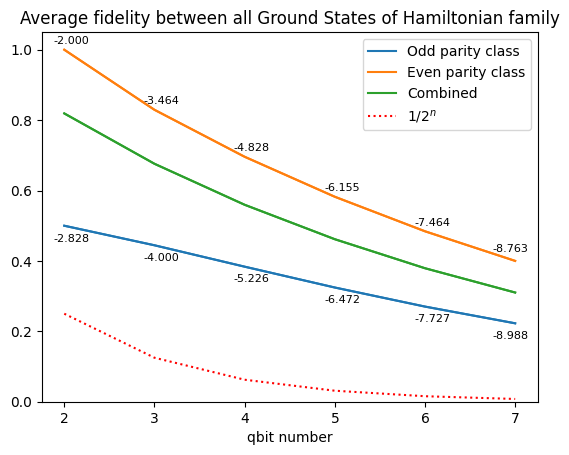

In [5]:
def fids(n):
    h=1
    seed=20
    disorder=True
    exactGSEs = []
    exactGSs = []
    h = jnp.repeat(h,n)
    cases= createDisorderTrainingCases(n,2**n,0,seed,None)
    for casei in cases:    
        ham = TFHamiltonianRevised(casei,h,disorder,(1,n))
        exactGSE=None
        _, exactGSE, GrStates = exactSolution(qml.matrix(ham)) # exactGSs is already normalised here
        exactGSEs.append(exactGSE)
        exactGSs.append(GrStates)

    tol = 1e-6
    # Step 1: Identify GSE buckets
    counts = count_similar_values(exactGSEs, tol=tol)
    GSE_keys = sorted(counts.keys())  # should be two unique GSEs
    print(GSE_keys)
    # Step 2: Split into two groups
    cases1, exactGSs1 = [], []
    cases2, exactGSs2 = [], []

    for case, gse, gs in zip(cases, exactGSEs, exactGSs):
        
        key = round(gse / tol) * tol
        tol = 1e-3
        if abs(key - GSE_keys[0]) < tol:
            cases1.append(case)
            exactGSs1.append(gs)
        else:
            cases2.append(case)
            exactGSs2.append(gs)

    print(f"Group 1 count: {len(cases1)}")
    print(f"Group 2 count: {len(cases2)}")
    assert len(cases1) + len(cases2) == len(cases)

    def fidel1case(exactGSs):
        fidelity= 0
        count = 0
        for i in range(len(exactGSs)):
            for j in range(i + 1, len(exactGSs)):
                fi = qml.math.fidelity_statevector(exactGSs[i].flatten(), exactGSs[j].flatten())
                fidelity += fi
                count += 1

        average_fidelity = fidelity / count
        return average_fidelity
    
    fidPerGroup = []
    fidPerGroup.append(float(fidel1case(exactGSs1))) #internal to energy
    fidPerGroup.append(float(fidel1case(exactGSs2)))
    fidPerGroup.append(float(fidel1case(exactGSs)))
    print("gr",fidPerGroup)
    return GSE_keys, fidPerGroup


fidss = []
GSEKeys = []
qbits = np.array([2,3,4,5,6,7])
for i in qbits:
    GSE_keys,val = fids(i)
    fidss.append(val)
    GSEKeys.append(GSE_keys)
print(fidss)

case1_vals = [x[0] for x in fidss]
case2_vals = [x[1] for x in fidss]
both_vals  = [x[2] for x in fidss]

# def exp_decay(x, a, b, c):
#     return a * np.exp(-b * x) + c

# # Fit the curve
# from scipy.optimize import curve_fit
# params, _ = curve_fit(exp_decay, qbits, case2_vals)
# qbits_extended = np.arange(2, 25)
# fids_fitted = exp_decay(qbits_extended, *params)
# plt.plot(qbits_extended, fids_fitted, '-', label='Fit', color='purple')

labels = ["Even parity class", "Odd parity class"]
J = jnp.repeat(1,2) #this is in the even parity class
_, exactGSE, GrStates = exactSolution(qml.matrix(TFHamiltonianRevised(J,J,False,(1,2))))
print(exactGSE)
if abs(exactGSE - case1_vals[0]) > 1e-4: labels = labels[::-1] #this swaps the order of labels if needed

plt.plot(qbits, case1_vals, label=labels[0], color='C0') 
plt.plot(qbits, case2_vals, label=labels[1], color='C1')  
plt.plot(qbits, both_vals,  label='Combined',   color='C2') 
plt.plot(qbits, 1/2**qbits, label = r"$1/2^{n}$", linestyle = 'dotted', color = 'red')
for i, x in enumerate(qbits):
    if x == qbits[-1]:
        plt.text(x - 0.25, case2_vals[i] + 0.02, f"{GSEKeys[i][1]:.3f}", fontsize=8, ha='left', va='bottom')
        plt.text(x - 0.25, case1_vals[i] - 0.05, f"{GSEKeys[i][0]:.3f}", fontsize=8, ha='left', va='bottom')
    else:
        plt.text(x - 0.12, case2_vals[i] + 0.01, f"{GSEKeys[i][1]:.3f}", fontsize=8, ha='left', va='bottom')
        plt.text(x - 0.12, case1_vals[i] - 0.05, f"{GSEKeys[i][0]:.3f}", fontsize=8, ha='left', va='bottom')


plt.legend()
plt.plot(qbits,fidss)
plt.title('Average fidelity between all Ground States of Hamiltonian family')
plt.xlabel('qbit number')
plt.xticks(qbits)
plt.ylim(0,1.05)
plt.show()

# diff =  fids_fitted/(1/2**qbits_extended)
# print(diff)
# plt.plot(qbits_extended, diff, '-', label='Fit', color='purple')
# plt.yscale('log')
# plt.show()

#count_similar_values(exactGSEs, tol=1e-12)

In [6]:
# J = np.random.choice([-1, 1], size=n-1) # random disordered couplings
# DisorderedHamiltonian = TFHamiltonianRevised(J,h,(1,n)) 
# # 
# # state,wires = initialState(J,n,True)
# # psi0 = qml.BasisState(state=state, wires=wires)
# # print(J)
# # print(psi0)

# expVal(J,n,DisorderedHamiltonian,True)

graphs for report

In [7]:
# # Learning rates
# lrs = np.array([1e-3, 2e-3, 5e-3])

# # Dataset: (reference energies, energy matrix)
# datasets = [
#     ([-7.55186995, -7.46410162, -7.72740661, -7.46410162],
#      [[-7.54780054, -7.54930257, -7.54004425],
#       [-7.4622185,  -7.46242747, -7.45489231],
#       [-7.71990572, -7.72300029, -7.70996822],
#       [-7.4612774,  -7.46247994, -7.45527223]]),

#     ([-7.55186995, -7.72740661, -7.46410162, -7.46410162],
#      [[-7.54564128, -7.47668259, -7.51407235],
#       [-7.71414867, -7.64011357, -7.61672015],
#       [-7.4609543,  -7.38465425, -7.46266748],
#       [-7.46182088, -7.40527995, -7.46282942]]),

#     ([-7.55186995, -7.46410162, -7.46410162, -7.72740661],
#      [[-7.51489807, -7.54434851, -7.51544427],
#       [-7.46181425, -7.45977154, -7.46280222],
#       [-7.46317202, -7.45802403, -7.46264681],
#       [-7.61970794, -7.71524997, -7.62088378]]),

#     ([-7.63963828, -7.46410162, -7.72740661, -7.72740661],
#      [[-7.63641276, -7.52750528, -7.57483528],
#       [-7.45776834, -7.39388634, -7.37750699],
#       [-7.72616787, -7.61868747, -7.6877916],
#       [-7.72530208, -7.56994204, -7.65920724]]),

#     ([-7.63963828, -7.72740661, -7.72740661, -7.46410162],
#      [[-7.59706358, -7.63913716, -7.62427221],
#       [-7.70308446, -7.72691838, -7.72640659],
#       [-7.69423883, -7.72723656, -7.72577545],
#       [-7.39386746, -7.46325655, -7.4206346]]),

#     ([-7.63963828, -7.72740661, -7.46410162, -7.72740661],
#      [[-7.62151959, -7.56808017, -7.56747517],
#       [-7.70658437, -7.61996172, -7.61912274],
#       [-7.44953304, -7.45880597, -7.46182911],
#       [-7.70844138, -7.62547282, -7.62147367]]),

#     ([-7.55186995, -7.46410162, -7.72740661, -7.46410162],
#      [[-7.52181862, -7.55062382, -7.49561928],
#       [-7.46319356, -7.4634897,  -7.43757551],
#       [-7.63938096, -7.7250963,  -7.61137095],
#       [-7.46288133, -7.46328546, -7.43791138]]),

#     ([-7.55186995, -7.46410162, -7.46410162, -7.72740661],
#      [[-7.51393272, -7.54646231,-7.49314451],
#       [-7.44588388 ,-7.46172474,-7.49],
#       [-7.44028957 ,-7.46196342,-7.49],
#       [-7.65562473 ,-7.71569878,-7.49]])
# ]

# # Set up plot
# plt.figure(figsize=(10, 6))
# cmap = plt.get_cmap('tab10')

# # Plot each seed
# for i, (refs, matrix) in enumerate(datasets):
#     refs = np.array(refs).reshape(-1, 1)  # shape (4, 1)
#     matrix = np.array(matrix)            # shape (4, 3)
#     rel_errors = np.abs(matrix - refs) / np.abs(refs)

#     color = cmap(i % 10)
#     plt.plot(lrs, rel_errors[0], color=color, linewidth=1, alpha=0.25)
# avg_global = np.mean([np.abs(np.array(matrix[0]) - refs[0]) / np.abs(refs[0]) for refs, matrix in datasets], axis=0)
# plt.plot(lrs, avg_global, color="black", linewidth=2, alpha=1)
# # Final touches
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Learning Rate')
# plt.ylabel('Relative Energy Difference')
# plt.title('6 qbits, 5 layers, 3 training cases, Erel to Eglobal')
# plt.grid(True, linestyle='--', alpha=0.5)

# # Legend for global lines only
# from matplotlib.lines import Line2D
# legend_lines = [Line2D([0], [0], color=cmap(i), lw=2) for i in range(len(datasets))]
# legend_labels = [f'Seed {i+1}' for i in range(len(datasets))]
# plt.legend(legend_lines, legend_labels, title='Global Descent', loc='lower right', fontsize='small')

# plt.tight_layout()
# plt.show()


In [8]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Reference value
# ref = -7.55186995
# layers = np.array([4, 5, 6])

# # Raw data (3 rows of 6 values each)
# data = np.array([
#     [-7.47366729, -7.54564128, -7.54716387, -7.47366729, -7.53534562, -7.55008777],
#     [-7.48875668, -7.51489807, -7.52165949, -7.48875668, -7.53264066, -7.55133601],
#     [-7.42620669, -7.54780054, -7.51530922, -7.42620669, -7.54565298, -7.55024367]
# ])

# # Compute relative differences to ref
# rel_diff = np.abs(data - ref) / np.abs(ref)

# # Set up plot
# plt.figure(figsize=(8, 5))
# cmap = plt.get_cmap('tab10')

# # Plot each row (solid for cols 0–2, dotted for cols 3–5)
# for i in range(3):
#     color = cmap(i)
#     plt.plot(layers, rel_diff[i, :3], label=f'Seed {i+1}', color=color, alpha=0.5)
#     plt.plot(layers, rel_diff[i, 3:], linestyle='dotted', color=color, alpha=0.5)

# # Compute and plot mean lines
# mean_solid = np.mean(rel_diff[:, :3], axis=0)
# mean_dotted = np.mean(rel_diff[:, 3:], axis=0)
# plt.plot(layers, mean_solid, color='black', label='Mean (solid)', linewidth=2)
# plt.plot(layers, mean_dotted, color='black', linestyle='dotted', label='Mean (dotted)', linewidth=2)

# # Final touches
# plt.xlabel('Number of Layers')
# plt.xticks(layers)
# plt.ylabel('Erel')
# plt.yscale('log')
# plt.title('Relative Energy Differences by Layer Count')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()


In [9]:
# # Learning rates
# lrs = np.array([1e-3, 3e-3, 9e-3])

# # Dataset: (reference energies, energy matrix)
# datasets = [
#     ([-7.57694661],
#      [[-7.52261643, -7.45594435, -7.43853912]]),

#      ([-7.57694661],
#      [[-7.46997458, -7.47194529, -7.49309141]]),

#      ([-7.57694661],
#      [[-7.47243282, -7.4689749, -7.42716054]])
# ]

# # Set up plot
# plt.figure(figsize=(10, 6))
# cmap = plt.get_cmap('tab10')

# # Plot each seed
# for i, (refs, matrix) in enumerate(datasets):
#     refs = np.array(refs).reshape(-1, 1)  # shape (4, 1)
#     matrix = np.array(matrix)            # shape (4, 3)
#     rel_errors = np.abs(matrix - refs) / np.abs(refs)

#     color = cmap(i % 10)
#     plt.plot(lrs, rel_errors[0], color=color, linewidth=1, alpha=0.45)
# avg_global = np.mean([np.abs(np.array(matrix[0]) - refs[0]) / np.abs(refs[0]) for refs, matrix in datasets], axis=0)
# plt.plot(lrs, avg_global, color="black", linewidth=2, alpha=1)
# # Final touches
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Learning Rate')
# plt.ylabel('Relative Energy Difference')
# plt.title('6 qbits, 5 layers, 7 training cases, Erel to Eglobal')
# plt.grid(True, linestyle='--', alpha=0.3)

# # Legend for global lines only
# from matplotlib.lines import Line2D
# legend_lines = [Line2D([0], [0], color=cmap(i), lw=2) for i in range(len(datasets))]
# legend_labels = [f'Seed {i+1}' for i in range(len(datasets))]
# plt.legend(legend_lines, legend_labels, title='Global Descent', loc='lower right', fontsize='small')

# plt.tight_layout()
# plt.show()


In [10]:
# # Reference value
# ref = [[-7.57694661],[-7.61456161],[-7.57694661]]
# layers = np.array([4, 5, 6])

# # Raw data (3 rows of 6 values each)
# data = np.array([
#     [-7.47390752, -7.52261643, -7.56142258, -7.47390752, -7.53219891, -7.57116014],
#     [-7.4641393, -7.56024239, -7.49621119, -7.4641393, -7.50722578, -7.521263],
#     [-7.43585729, -7.46885631, -7.55258692, -7.43585729, -7.54374722, -7.57048206]
# ])

# # Compute relative differences to ref
# rel_diff = np.abs(data - ref) / np.abs(ref)

# # Set up plot
# plt.figure(figsize=(8, 5))
# cmap = plt.get_cmap('tab10')

# # Plot each row (solid for cols 0–2, dotted for cols 3–5)
# for i in range(data.shape[0]):
#     color = cmap(i)
#     plt.plot(layers, rel_diff[i, :3], label=f'Seed {i+1}', color=color, alpha=0.5)
#     plt.plot(layers, rel_diff[i, 3:], linestyle='dotted', color=color, alpha=0.5)

# # Compute and plot mean lines
# mean_solid = np.mean(rel_diff[:, :3], axis=0)
# mean_dotted = np.mean(rel_diff[:, 3:], axis=0)
# plt.plot(layers, mean_solid, color='black', label='Mean (solid)', linewidth=2)
# plt.plot(layers, mean_dotted, color='black', linestyle='dotted', label='Mean (dotted)', linewidth=2)

# # Final touches
# plt.xlabel('Number of Layers')
# plt.xticks(layers)
# plt.ylabel('Erel')
# plt.yscale('log')
# plt.title('Relative Energy Differences by Layer Count')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()


In [11]:
# # Learning rates
# lrs = np.array([0.0005, 0.001, 0.002])

# # Dataset: (reference energies, energy matrix)
# datasets = [
#      ([-7.57694661 ],
#      [[-7.41657322, -7.52412564, -7.42526169]]),
#      ([-7.59575411],
#      [[-7.48208203, -7.54155386, -7.5512062 ]]),
#      ([-7.59575411 ],
#      [[-7.51784584, -7.54305808, -7.45464773]])
# ]

# # Set up plot
# plt.figure(figsize=(10, 6))
# cmap = plt.get_cmap('tab10')

# # Plot each seed
# for i, (refs, matrix) in enumerate(datasets):
#     refs = np.array(refs).reshape(-1, 1)  # shape (4, 1)
#     matrix = np.array(matrix)            # shape (4, 3)
#     rel_errors = np.abs(matrix - refs) / np.abs(refs)

#     color = cmap(i % 10)
#     plt.plot(lrs, rel_errors[0], color=color, linewidth=1, alpha=0.45)
# avg_global = np.mean([np.abs(np.array(matrix[0]) - refs[0]) / np.abs(refs[0]) for refs, matrix in datasets], axis=0)
# plt.plot(lrs, avg_global, color="black", linewidth=2, alpha=1)
# # Final touches
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Learning Rate')
# plt.ylabel('Relative Energy Difference')
# plt.title('6 qbits, 5 layers, 14 training cases, Erel to Eglobal')
# plt.grid(True, linestyle='--', alpha=0.3)

# # Legend for global lines only
# from matplotlib.lines import Line2D
# legend_lines = [Line2D([0], [0], color=cmap(i), lw=2) for i in range(len(datasets))]
# legend_labels = [f'Seed {i+1}' for i in range(len(datasets))]
# plt.legend(legend_lines, legend_labels, title='Global Descent', loc='lower right', fontsize='small')

# plt.tight_layout()
# plt.show()


In [12]:
# # Reference value
# ref = [[-7.57694661],[-7.59575411 ],[-7.59575411 ]]
# layers = np.array([5, 6, 7])

# # Raw data (3 rows of 6 values each)
# data = np.array([
#     [-7.44443565, -7.52412564, -7.48635967, -7.44443565, -7.49026099, -7.51982194],
#     [-7.53543097, -7.54155386, -7.54221825, -7.53543097, -7.57411033, -7.58481329],
#     [-7.47850134, -7.54305808, -7.49157299, -7.47850134, -7.56727217, -7.58486291]
# ])

# # Compute relative differences to ref
# rel_diff = np.abs(data - ref) / np.abs(ref)

# # Set up plot
# plt.figure(figsize=(8, 5))
# cmap = plt.get_cmap('tab10')

# # Plot each row (solid for cols 0–2, dotted for cols 3–5)
# for i in range(data.shape[0]):
#     color = cmap(i)
#     plt.plot(layers, rel_diff[i, :3], label=f'Seed {i+1}', color=color, alpha=0.5)
#     plt.plot(layers, rel_diff[i, 3:], linestyle='dotted', color=color, alpha=0.5)

# # Compute and plot mean lines
# mean_solid = np.mean(rel_diff[:, :3], axis=0)
# mean_dotted = np.mean(rel_diff[:, 3:], axis=0)
# plt.plot(layers, mean_solid, color='black', label='Mean (solid)', linewidth=2)
# plt.plot(layers, mean_dotted, color='black', linestyle='dotted', label='Mean (dotted)', linewidth=2)

# # Final touches
# plt.xlabel('Number of Layers')
# plt.xticks(layers)
# plt.ylabel('Erel')
# plt.yscale('log')
# plt.title('Relative Energy Differences by Layer Count')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()


[[0.01816423 0.10229922 0.13398287 0.12744003]
 [5.30984218 2.33466536 0.14520631 0.14126821]]


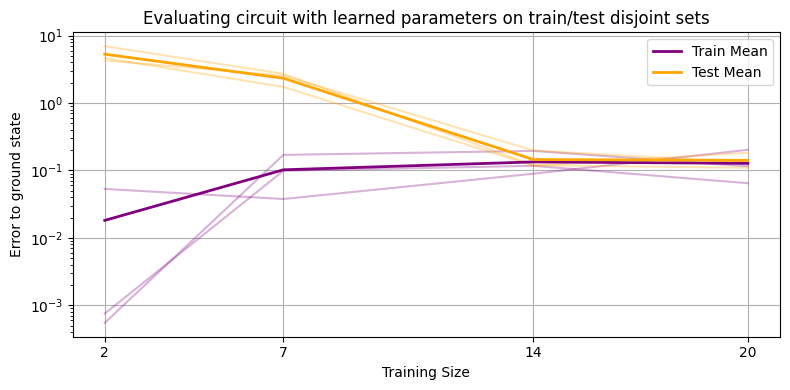

In [13]:
# training set size
lrs = np.array([2,7,14,20])

# Dataset: (reference energies, energy matrix)
data = [ [[0.0005481937792271019, 0.17032911608707071, 0.19517225950870357, 0.11516217312345844], 
          [4.288048960620666, 2.5496905628901225, 0.19814150485980742, 0.13080667211025504]    ], 
              [[0.053191586030973514, 0.037726971033335666, 0.08956471189612504, 0.20247014498744464], 
               [4.660620785890334, 1.7349487516087463, 0.1179599808929277, 0.1833206731996636] ],
               [[0.0007529149867200324, 0.09884156390397841, 0.11721162554675527, 0.06468775978388829],
                [6.9808567920765245, 2.7193567566684043, 0.11951744553309362, 0.10967727570714109]]
]

colors = ['purple', 'orange']
labels = ['Train', 'Test']

plt.figure(figsize=(8, 4))

for group in data:
    group = np.array(group)  # shape: (seeds, T)
    
    # Plot each individual seed
    for i, run in enumerate(group):
        plt.plot(lrs, run, color=colors[i], alpha=0.3)

# Plot mean across seeds
mean = np.mean(data, axis=0)
print(mean)
for i in range(2):
    plt.plot(lrs, mean[i], color=colors[i], linewidth=2, label=f'{labels[i]} Mean')


plt.xlabel('Training Size')
plt.ylabel('Error to ground state')
plt.title('Evaluating circuit with learned parameters on train/test disjoint sets')
plt.yscale('log')
plt.xticks(lrs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Architecture plotting functions

C:\Users\asutc\AppData\Local\Temp\ipykernel_17452\1785880564.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


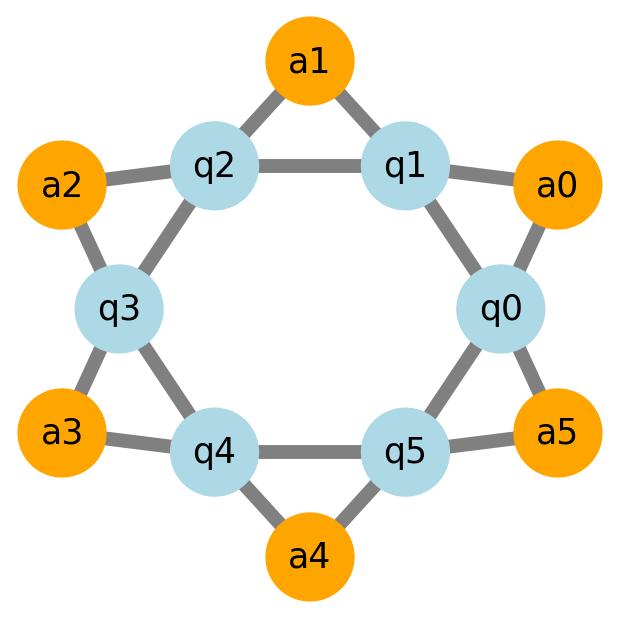

In [ ]:
# import networkx as nx
# n = 6  # Number of main qubits (and ancillas)

# G = nx.Graph()

# # Add qubit and ancilla nodes
# qubit_labels = [f'q{i}' for i in range(n)]
# ancilla_labels = [f'a{i}' for i in range(n)]

# # Place main qubits in a circle
# angle_step = 2 * np.pi / n
# radius = 1.0
# pos = {}
# for i, q in enumerate(qubit_labels):
#     angle = i * angle_step
#     pos[q] = (radius * np.cos(angle), radius * np.sin(angle))

# # Place ancillas midway between qubits
# ancilla_radius = 1.5
# for i, a in enumerate(ancilla_labels):
#     angle = (i + 0.5) * angle_step
#     pos[a] = (ancilla_radius * np.cos(angle), ancilla_radius * np.sin(angle))

# # Add edges: connect qubits in ring
# for i in range(n):
#     G.add_edge(qubit_labels[i], qubit_labels[(i + 1) % n])

# # Connect each ancilla to two adjacent qubits
# for i in range(n):
#     q1 = qubit_labels[i]
#     q2 = qubit_labels[(i + 1) % n]
#     a = ancilla_labels[i]
#     G.add_edge(a, q1)
#     G.add_edge(a, q2)

# # Draw the graph
# plt.figure(figsize=(6,6))
# nx.draw(
#     G, pos,
#     with_labels=True,
#     node_color=['lightblue' if n.startswith('q') else 'orange' for n in G.nodes()],
#     node_size=4000,
#     font_size=25,
#     edge_color='gray',
#     width= 10
# )
# plt.axis('off')
# plt.tight_layout()
# plt.show()


Matplotlib is building the font cache; this may take a moment.


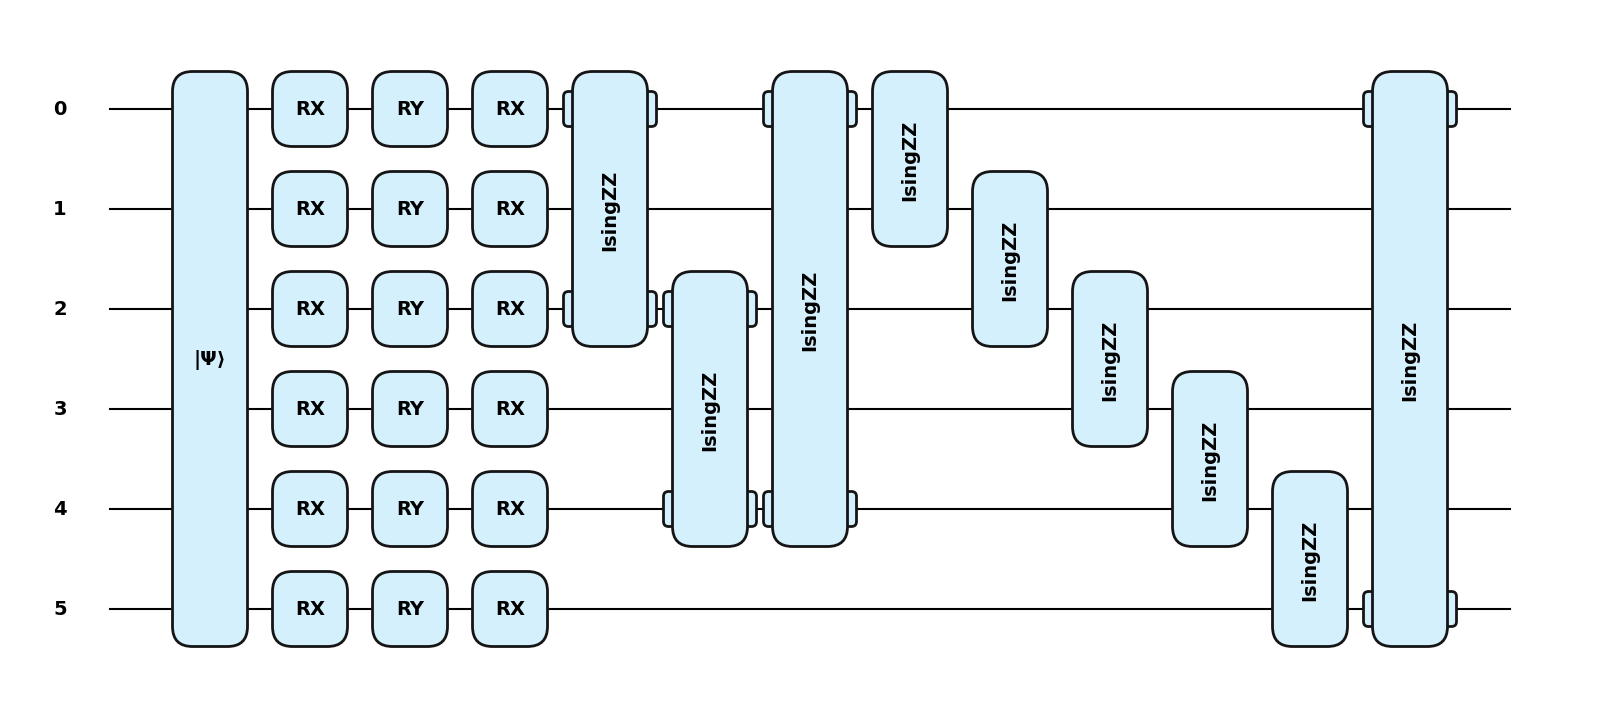

In [ ]:
# qml.drawer.use_style("pennylane")
# n=3
# fig, ax = qml.draw_mpl(ansatz, style="pennylane")(jnp.repeat(1,n), n, np.zeros_like(np.zeros((n, 9, 2))), 1, disorder=True)